### This notebook focuses on building intuition behind Ridge Regression by implementing it from scratch and comparing it with sklearn.


1. It compares a custom-built Ridge class with the built-in `sklearn` implementation.
2. It demonstrates how increasing the value of alpha decreases the slope (i.e., shrinks coefficients).
3. This implementation works only for a single feature and a single target variable.
   (A multi-dimensional Ridge implementation will be covered in a separate notebook.)

In [18]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X,Y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

In [19]:
X.shape

(100, 1)

<Axes: >

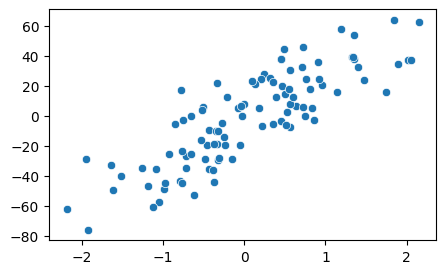

In [20]:
plt.figure(figsize=(5,3))
sns.scatterplot(x=X.ravel(),y=Y)


#### 1. Using Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X,Y)
print(LR.coef_)
print(LR.intercept_)

[27.82809103]
-2.29474455867698


#### 2. Using Ridge Regression

In [22]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=10)  # Alpha = 10
R.fit(X,Y)
print(R.coef_)
print(R.intercept_)

[24.9546267]
-2.1269130035235735


In [23]:
R1 = Ridge(alpha=100)  # Alpha = 100
R1.fit(X,Y)
print(R1.coef_)
print(R1.intercept_)

[12.93442104]
-1.4248441496033308


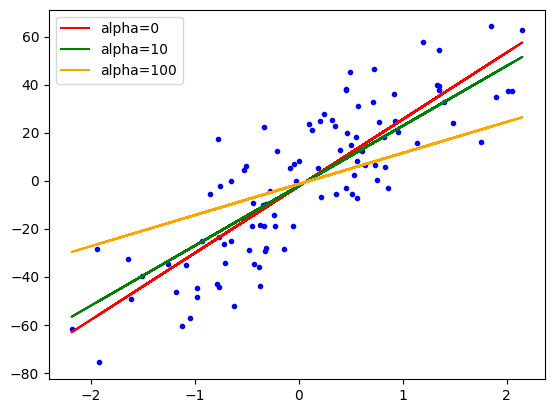

In [24]:
plt.plot(X,Y,'b.')
plt.plot(X,LR.predict(X),color='red',label='alpha=0')
plt.plot(X,R.predict(X),color='green',label='alpha=10')
plt.plot(X,R1.predict(X),color='orange',label='alpha=100')
plt.legend()

#### 3. Implementing Maths behind Ridge

In [25]:
class MyRidge:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.intercept_ = None
        self.coef_ = None

    def fit(self, x_train, y_train):
        x_bar = x_train.mean()
        y_bar = y_train.mean()

        num = 0
        den = 0

        for i in range(x_train.shape[0]):
            num += (y_train[i] - y_bar) * (x_train[i] - x_bar)
            den += (x_train[i] - x_bar) ** 2

        self.coef_ = num / (den + self.alpha)

        self.intercept_ = y_bar - (self.coef_ * x_bar)

        self.showVar()
        return self

    def predict(self, x_test):
        return self.coef_ * x_test + self.intercept_

    def showVar(self):
        print(f"coef_(m): {self.coef_}")
        print(f"intercept(b): {self.intercept_}")

In [26]:
a = MyRidge(10)
a.fit(X,Y)


coef_(m): [24.9546267]
intercept(b): [-2.126913]
